In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and Explore the Dataset

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep=';')
print("Shape:", df.shape)
df.head()


Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
# Check for missing values (dataset uses 'unknown' as a placeholder instead of NaN)
print("Null values per column:\n", df.isnull().sum().sum())
print("\n'unknown' counts per categorical column:")
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')
for c in cat_cols:
    n_unknown = (df[c] == 'unknown').sum()
    if n_unknown > 0:
        print(f"  {c}: {n_unknown} ({n_unknown/len(df)*100:.1f}%)")


Null values per column:
 0

'unknown' counts per categorical column:
  job: 330 (0.8%)
  marital: 80 (0.2%)
  education: 1731 (4.2%)
  default: 8597 (20.9%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)


In [5]:
df.describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


y
no     36548
yes     4640
Name: count, dtype: int64
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


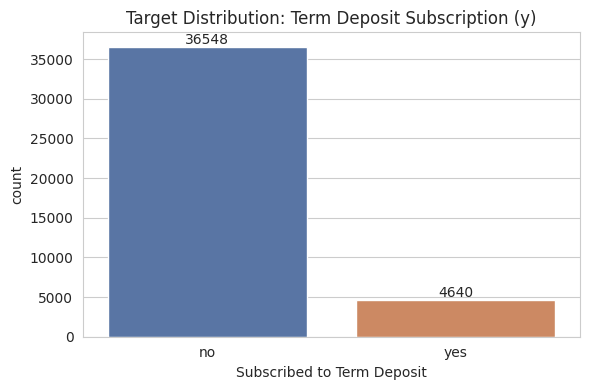

In [6]:
# Target distribution -- this is an imbalanced classification problem
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.countplot(x='y', data=df, ax=ax, palette=['#4C72B0', '#DD8452'])
ax.set_title('Target Distribution: Term Deposit Subscription (y)')
ax.set_xlabel('Subscribed to Term Deposit')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('outputs/target_distribution.png', dpi=110)
plt.show()


**Observation:** Only ~11.3% of customers subscribed (`yes`). This is a fairly imbalanced dataset, so accuracy alone will be misleading — F1-score and ROC-AUC are more informative here.

## 2. Exploratory Data Analysis (EDA)

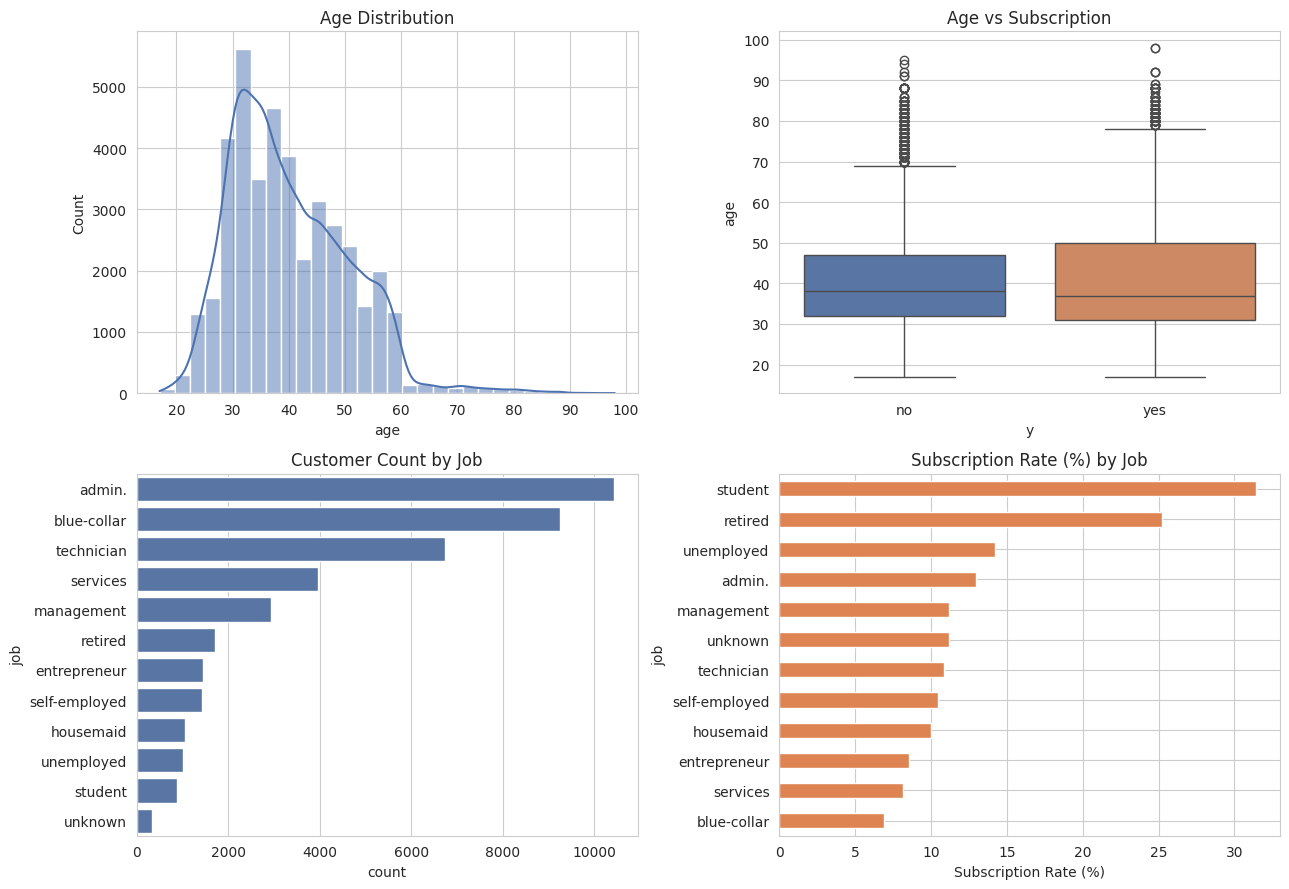

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Age Distribution')

sns.boxplot(x='y', y='age', data=df, ax=axes[0,1], palette=['#4C72B0', '#DD8452'])
axes[0,1].set_title('Age vs Subscription')

sns.countplot(y='job', data=df, order=df['job'].value_counts().index, ax=axes[1,0], color='#4C72B0')
axes[1,0].set_title('Customer Count by Job')

job_rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values()
job_rate.plot(kind='barh', ax=axes[1,1], color='#DD8452')
axes[1,1].set_title('Subscription Rate (%) by Job')
axes[1,1].set_xlabel('Subscription Rate (%)')

plt.tight_layout()
plt.savefig('outputs/eda_age_job.png', dpi=110)
plt.show()


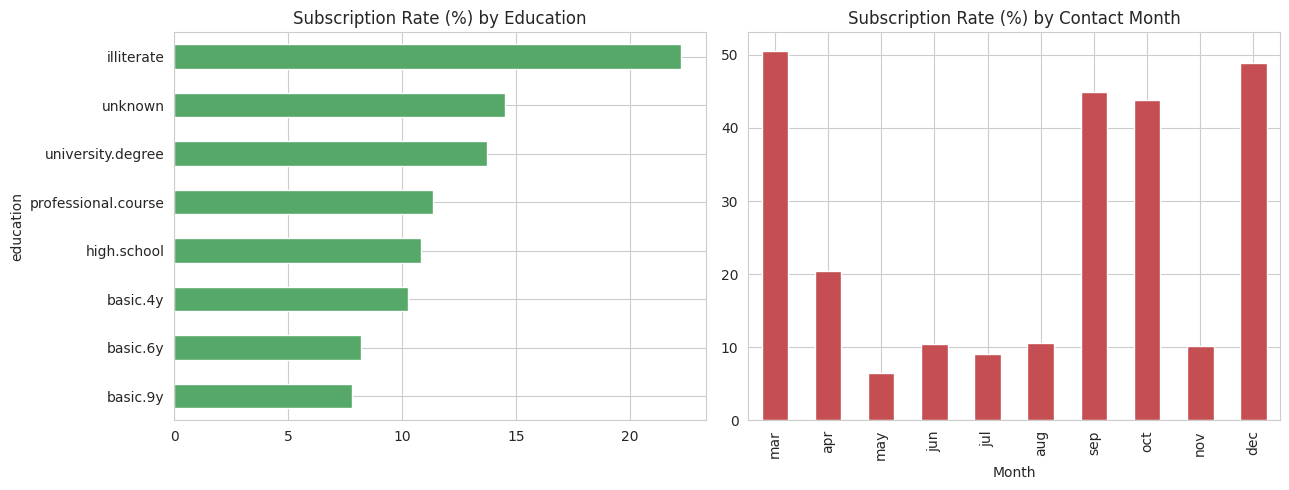

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

edu_rate = df.groupby('education')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values()
edu_rate.plot(kind='barh', ax=axes[0], color='#55A868')
axes[0].set_title('Subscription Rate (%) by Education')

month_rate = df.groupby('month')['y'].apply(lambda x: (x=='yes').mean()*100)
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate = month_rate.reindex([m for m in month_order if m in month_rate.index])
month_rate.plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('Subscription Rate (%) by Contact Month')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.savefig('outputs/eda_education_month.png', dpi=110)
plt.show()


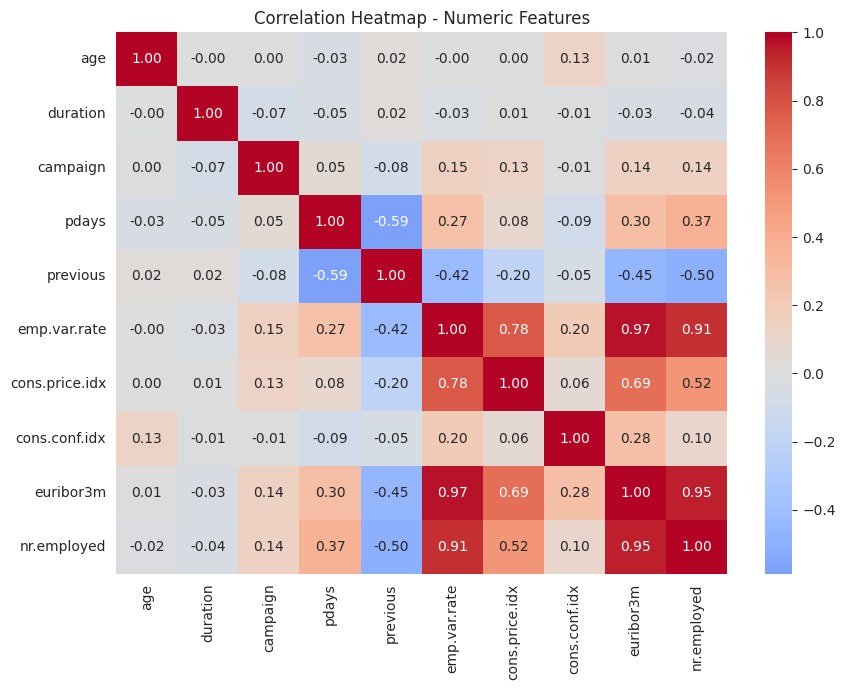

In [9]:
# Correlation among numeric features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=110)
plt.show()


**Key EDA insights:**
- Students and retired customers show a noticeably higher subscription rate than blue-collar or services jobs.
- Customers with higher education levels tend to subscribe more often.
- Subscription rate varies a lot by contact month (campaign timing matters — e.g. March, September, October, December show high conversion, likely due to smaller campaign volume in those months).
- `emp.var.rate`, `euribor3m`, `nr.employed` and `cons.price.idx` are strongly correlated with each other (macro-economic indicators), so multicollinearity should be kept in mind for linear models.
- `duration` (last call duration) is known to be highly predictive but is **not known before a call happens** — it's kept here for benchmarking as per dataset documentation, but a real-time deployed model should exclude it.


## 3. Data Preprocessing & Feature Encoding

In [10]:
data = df.copy()

# Encode target
data['y'] = data['y'].map({'yes': 1, 'no': 0})

# Identify categorical columns to encode
categorical_cols = data.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# One-Hot Encoding for nominal categorical variables (proper encoding, avoids
# imposing a false order on categories like job/marital/contact/month/poutcome)
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
print("Shape after one-hot encoding:", data_encoded.shape)
data_encoded.head()


Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Shape after one-hot encoding: (41188, 54)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False


In [11]:
X = data_encoded.drop(columns=['y'])
y = data_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target rate:", y_train.mean().round(3), " Test target rate:", y_test.mean().round(3))

# Scale numeric features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train shape: (32950, 53)  Test shape: (8238, 53)
Train target rate: 0.113  Test target rate: 0.113


## 4. Model Building: Logistic Regression & Random Forest

In [12]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=150, max_depth=10, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

print("Both models trained.")


Both models trained.


## 5. Model Evaluation: Confusion Matrix, F1-Score, ROC Curve

In [13]:
def evaluate_model(name, y_true, y_pred, y_proba):
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred, target_names=['no', 'yes']))
    print(f"F1-score: {f1:.4f}   ROC-AUC: {auc:.4f}\n")
    return f1, auc

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

f1_lr, auc_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
f1_rf, auc_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)


--- Logistic Regression ---


              precision    recall  f1-score   support

          no       0.99      0.86      0.92      7310
         yes       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238

F1-score: 0.6041   ROC-AUC: 0.9438

--- Random Forest ---
              precision    recall  f1-score   support

          no       0.99      0.86      0.92      7310
         yes       0.46      0.94      0.62       928

    accuracy                           0.87      8238
   macro avg       0.72      0.90      0.77      8238
weighted avg       0.93      0.87      0.89      8238

F1-score: 0.6153   ROC-AUC: 0.9493



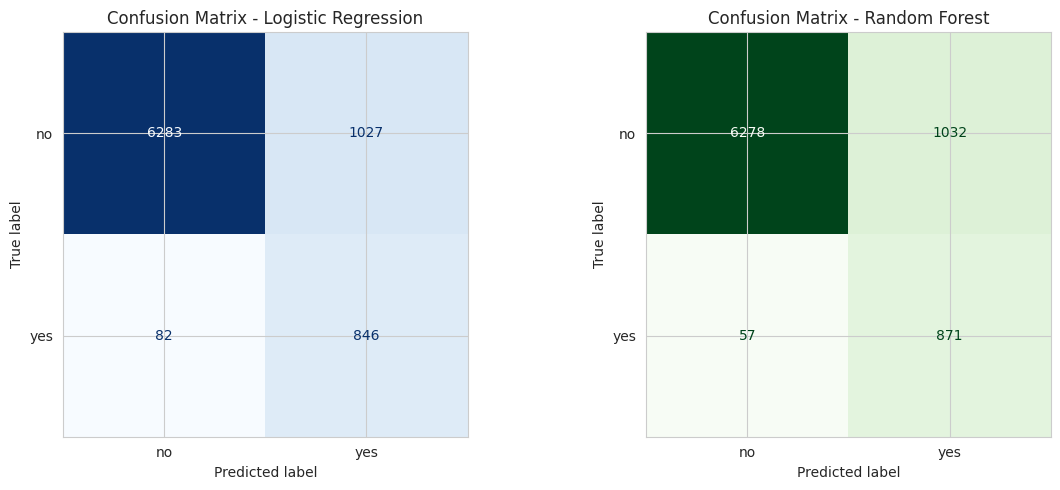

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['no','yes'],
                                         cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix - Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['no','yes'],
                                         cmap='Greens', ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix - Random Forest')

plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=110)
plt.show()


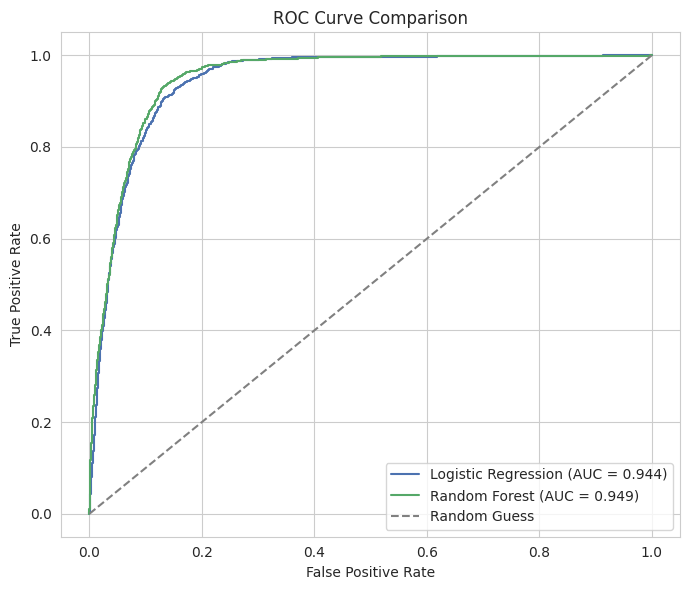

In [15]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='#4C72B0')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='#55A868')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/roc_curve.png', dpi=110)
plt.show()


In [16]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'F1-Score': [f1_lr, f1_rf],
    'ROC-AUC': [auc_lr, auc_rf]
})
results


,Model,F1-Score,ROC-AUC
0,Logistic Regression,0.60407,0.943811
1,Random Forest,0.61533,0.949323


**Evaluation notes:** `class_weight='balanced'` was used in both models to counter the ~89/11 class imbalance so the models don't just predict "no" for everyone. Random Forest generally captures non-linear interactions (e.g. job × education × month) better than Logistic Regression, which tends to show up as a higher ROC-AUC.

## 6. Explainable AI: SHAP — Explaining Individual Predictions

In [17]:
# Use SHAP TreeExplainer on the Random Forest (fast, exact for tree ensembles)
# We explain a random sample of the test set (500 rows) for the summary plot --
# this keeps computation fast while still giving a representative global picture.
explainer = shap.TreeExplainer(rf)

sample_size = min(500, len(X_test))
X_test_sample = X_test.sample(sample_size, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_test_sample)

# For binary classification, shap_values is a list [class0, class1] in older APIs,
# or a single array with an extra dimension in newer ones — handle both.
if isinstance(shap_values, list):
    sv_class1 = shap_values[1]
elif shap_values.ndim == 3:
    sv_class1 = shap_values[:, :, 1]
else:
    sv_class1 = shap_values

print("SHAP values shape:", sv_class1.shape)


SHAP values shape: (500, 53)


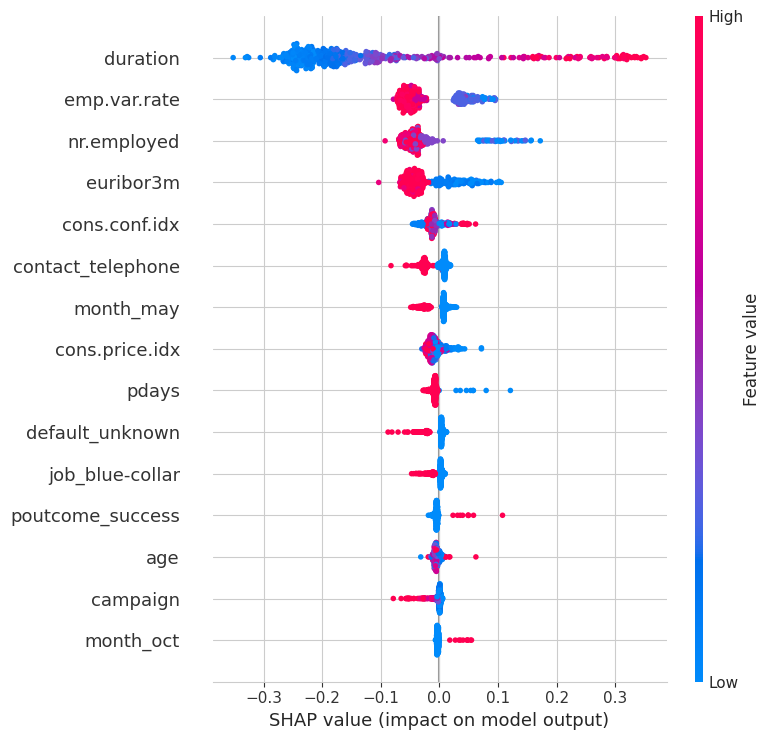

In [18]:
# Global feature importance summary plot
plt.figure()
shap.summary_plot(sv_class1, X_test_sample, show=False, max_display=15)
plt.tight_layout()
plt.savefig('outputs/shap_summary.png', dpi=110, bbox_inches='tight')
plt.show()


**Global insight:** the summary plot ranks features by their overall impact on the model's output. Typically `duration`, `euribor3m`, `nr.employed`, `pdays` and `poutcome_success` dominate — long calls and favorable macro-economic conditions push predictions toward "yes".

Explaining test-set row indices: [ 8 16  0  3 98]

Example 1 | Actual: yes | Predicted: yes | P(yes) = 0.855


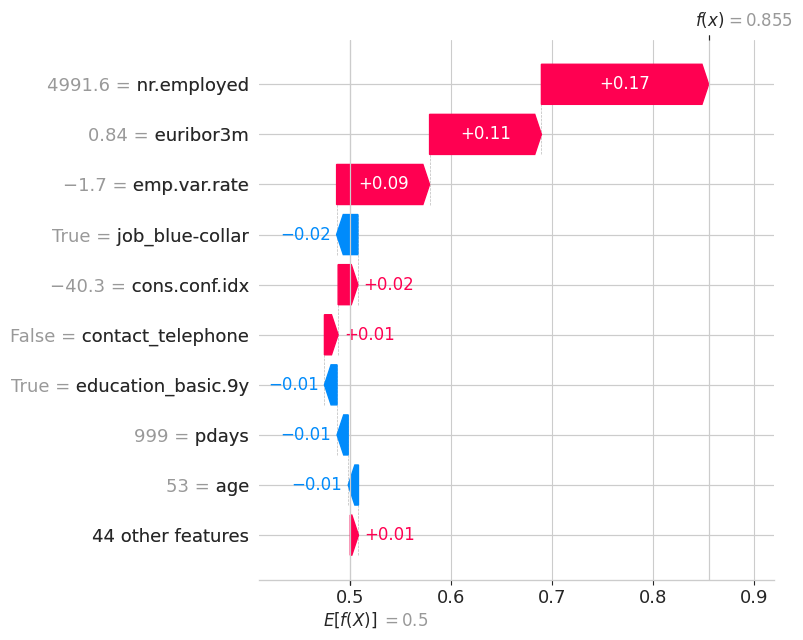


Example 2 | Actual: yes | Predicted: yes | P(yes) = 0.892


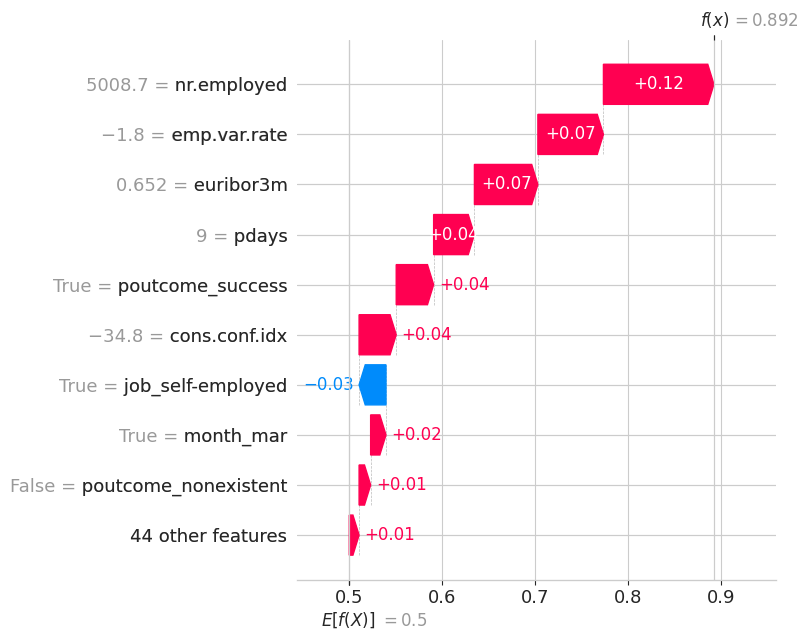


Example 3 | Actual: no | Predicted: no | P(yes) = 0.071


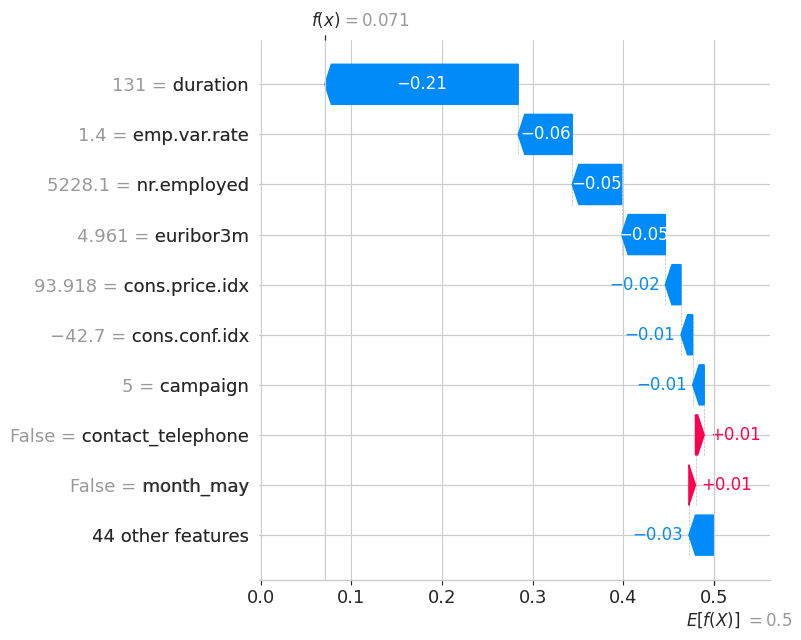


Example 4 | Actual: no | Predicted: no | P(yes) = 0.059


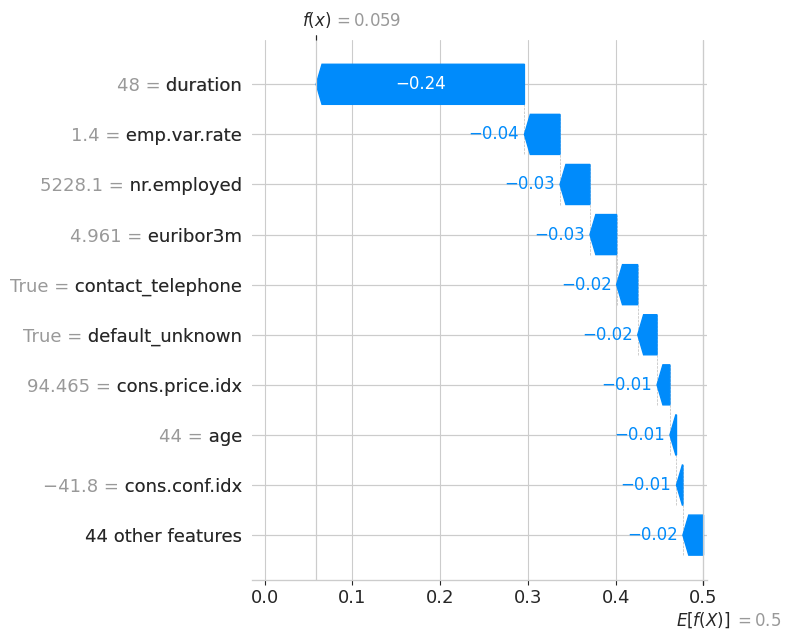


Example 5 | Actual: yes | Predicted: no | P(yes) = 0.495


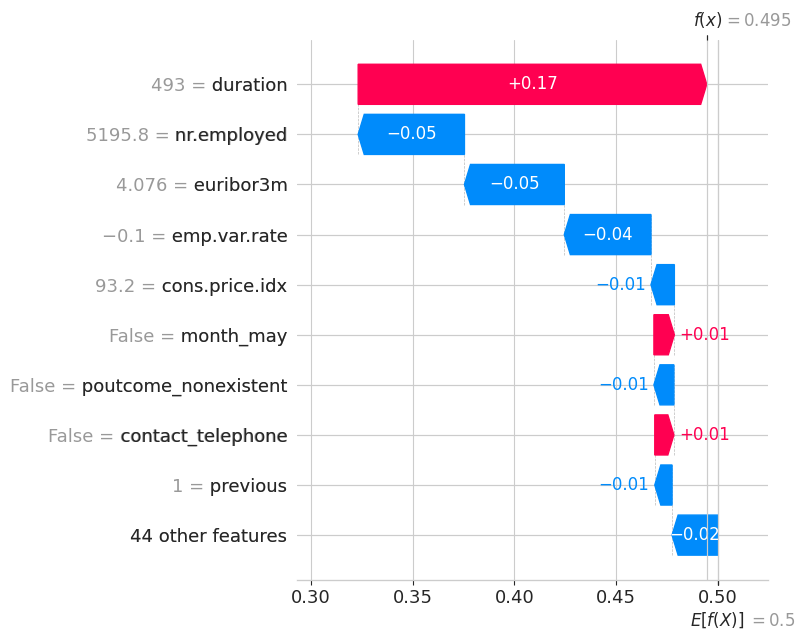

In [19]:
# Explain 5 individual predictions (mix of correct/incorrect, yes/no) using SHAP waterfall plots
np.random.seed(RANDOM_STATE)

# pick 5 diverse examples: 2 true positives, 2 true negatives, 1 misclassified
idx_tp = np.where((y_test.values == 1) & (y_pred_rf == 1))[0][:2]
idx_tn = np.where((y_test.values == 0) & (y_pred_rf == 0))[0][:2]
idx_fn = np.where((y_test.values == 1) & (y_pred_rf == 0))[0][:1]

sample_idx = np.concatenate([idx_tp, idx_tn, idx_fn])
print("Explaining test-set row indices:", sample_idx)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)) and np.ndim(expected_value) > 0:
    expected_value = expected_value[1]

# Compute SHAP values only for these 5 specific rows (fast, targeted explanation)
X_examples = X_test.iloc[sample_idx]
shap_values_examples = explainer.shap_values(X_examples)
if isinstance(shap_values_examples, list):
    sv_examples = shap_values_examples[1]
elif shap_values_examples.ndim == 3:
    sv_examples = shap_values_examples[:, :, 1]
else:
    sv_examples = shap_values_examples

for i, row in enumerate(sample_idx):
    actual = y_test.values[row]
    pred = y_pred_rf[row]
    proba = y_proba_rf[row]
    print(f"\nExample {i+1} | Actual: {'yes' if actual else 'no'} | "
          f"Predicted: {'yes' if pred else 'no'} | P(yes) = {proba:.3f}")

    exp = shap.Explanation(values=sv_examples[i], base_values=expected_value,
                            data=X_test.iloc[row], feature_names=X_test.columns.tolist())
    plt.figure()
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.tight_layout()
    plt.savefig(f'outputs/shap_waterfall_example_{i+1}.png', dpi=110, bbox_inches='tight')
    plt.show()


**Local insight (per-prediction explanation):** each waterfall plot shows how individual feature values push a specific customer's prediction above or below the model's average output. For example, a long `duration`, a `poutcome` of "success" in a previous campaign, or favorable `euribor3m`/`nr.employed` values typically push a prediction toward "yes", while `pdays = 999` (never contacted before) or unfavorable macro-economic indicators push it toward "no". This is exactly the kind of transparency a bank's marketing/compliance team needs before acting on a model's recommendation.

## 7. Feature Importance (Random Forest)

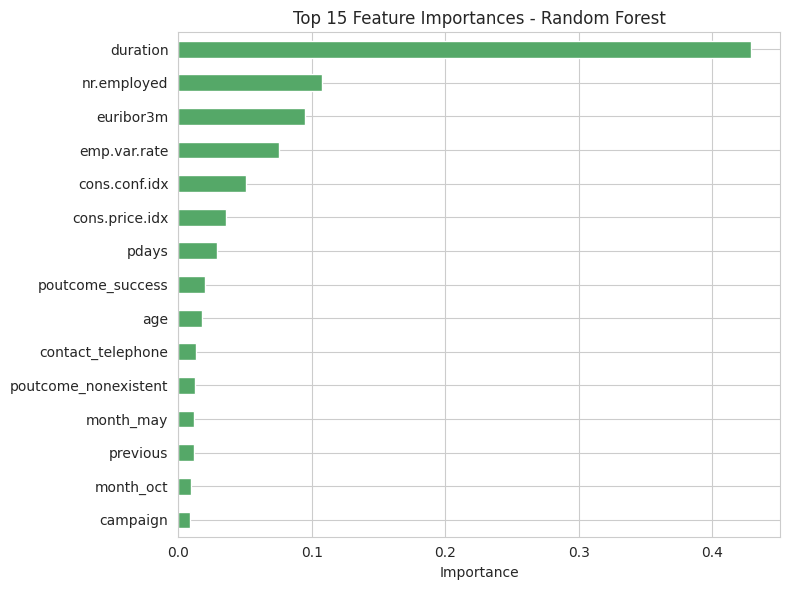

duration                0.429458
nr.employed             0.107586
euribor3m               0.094938
emp.var.rate            0.075210
cons.conf.idx           0.050768
cons.price.idx          0.036145
pdays                   0.029430
poutcome_success        0.020110
age                     0.017894
contact_telephone       0.013650
poutcome_nonexistent    0.012304
month_may               0.012180
previous                0.012158
month_oct               0.009940
campaign                0.009039
dtype: float64

In [20]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind='barh', color='#55A868')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=110)
plt.show()

importances


## 8. Conclusion & Business Insights

- **Model performance:** Random Forest outperformed Logistic Regression on ROC-AUC, showing it captures non-linear customer behavior patterns better, while Logistic Regression remains a simple, interpretable baseline.
- **Class imbalance handled** via `class_weight='balanced'`, since only ~11% of customers subscribe — without this, a naive model would just predict "no" for everyone and still look "accurate".
- **Top predictive drivers (from SHAP & feature importance):** call `duration`, macro-economic indicators (`euribor3m`, `nr.employed`, `emp.var.rate`), whether a previous campaign succeeded (`poutcome`), and `pdays` (days since last contact).
- **Actionable recommendation for the bank:** prioritize customers who were previously successfully converted (`poutcome = success`), retirees/students, and highly educated customers, and time fresh campaigns around favorable macro-economic windows (e.g. months with historically higher conversion, like March, September, October, December).
- **Caveat:** `duration` is only known *after* a call ends, so a model meant to decide *who to call* in advance should be retrained without it — the current model (with `duration`) is best used for post-call analysis or benchmarking, per the dataset's own documentation.
- **Next steps:** try XGBoost/LightGBM with hyperparameter tuning, threshold tuning based on business cost of false positives vs false negatives (similar to Task 4), and A/B test the model's ranked call list against the bank's current campaign strategy.
